# Predictive Maintenance — Remaining Useful Life (RUL) Estimation

Unplanned engine failures cost aerospace companies millions per incident. This project builds a RUL prediction model using the NASA C-MAPSS dataset, which simulates turbofan engine degradation under realistic operating conditions.

**Goal:** Given sensor readings from an engine's operational history, predict how many cycles remain before failure and quantify the uncertainty in that prediction.

**Models trained:**
1. **Random Forest** — fast baseline, operates on the last observed cycle only
2. **LSTM (point estimate)** — sequence model on 30-cycle rolling windows
3. **LSTM with Quantile Regression** — adds p5 / p50 / p95 uncertainty intervals

**Dataset:** FD001 from the NASA Prognostics Data Repository. Single operating condition, one fault mode (high-pressure compressor degradation). 100 training engines, 100 test engines.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader

In [2]:
torch.manual_seed(42)
np.random.seed(42)

## 1. Data Loading & Feature Selection

In [3]:
try:
    DATA_DIR = Path(__file__).resolve().parent.parent / "data"
except NameError:
    DATA_DIR = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path.cwd() / "data"

fd1_train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r'\s+', header=None)
fd1_test  = pd.read_csv(DATA_DIR / "test_FD001.txt",  sep=r'\s+', header=None)
rul_test  = pd.read_csv(DATA_DIR / "RUL_FD001.txt",   sep=r'\s+', header=None)

fd1_train.columns = ["unit_num", "cycles", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
fd1_test.columns = ["unit_num", "cycles", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
rul_test.columns = ["RUL"]

fd1_train.head()
fd1_train.describe()

,unit_num,cycles,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


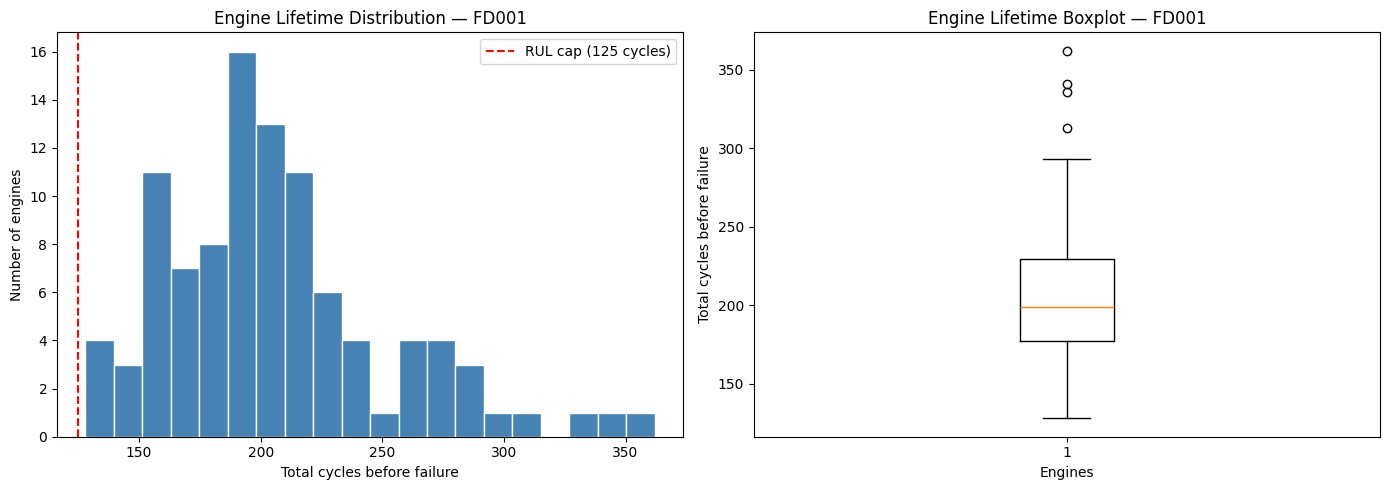

Min: 128  Median: 199  Max: 362
Engines with lifetime > 125 cycles: 100 / 100


In [4]:
max_life = fd1_train.groupby("unit_num")["cycles"].max()   # Series of length 100, indexed by unit_num

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# distribution of engine lifetimes
ax1.hist(max_life, bins=20, color="steelblue", edgecolor="white")
ax1.axvline(125, color="red", linestyle="--", label="RUL cap (125 cycles)")
ax1.set_xlabel("Total cycles before failure")
ax1.set_ylabel("Number of engines")
ax1.set_title("Engine Lifetime Distribution — FD001")
ax1.legend()

#  boxplot
ax2.boxplot(max_life)
ax2.set_xlabel("Engines")
ax2.set_ylabel("Total cycles before failure")
ax2.set_title("Engine Lifetime Boxplot — FD001")

plt.tight_layout()
plt.show()

print(f"Min: {max_life.min()}  Median: {max_life.median():.0f}  Max: {max_life.max()}")
print(f"Engines with lifetime > 125 cycles: {(max_life > 125).sum()} / {len(max_life)}")

fig.savefig('../figures/engine_lifetimes.png', dpi=150, bbox_inches='tight')

In [5]:
all_cols = ["op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

screen = fd1_train[all_cols].agg(["std", "nunique", "min", "max"]).T
screen["range"] = screen["max"] - screen["min"]
screen.sort_values("std")       

constant = screen.index[screen["nunique"] == 1].tolist()
print("Perfectly constant (drop):", constant)

# near-constant: real but negligible variation
near_constant = screen.index[(screen["nunique"] > 1) & (screen["std"] < 1e-2)].tolist()
print("Near-constant (likely drop):", near_constant)

Perfectly constant (drop): ['op3', 's1', 's5', 's10', 's16', 's18', 's19']
Near-constant (likely drop): ['op1', 'op2', 's6']


In [6]:
drop_cols = constant + near_constant   
fd1_train = fd1_train.drop(columns=drop_cols)

In [7]:
id_time_cols = ["unit_num", "cycles"]
kept_sensor_cols = [c for c in fd1_train.columns if c not in id_time_cols]
print(len(kept_sensor_cols), "sensors kept:", kept_sensor_cols)

14 sensors kept: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


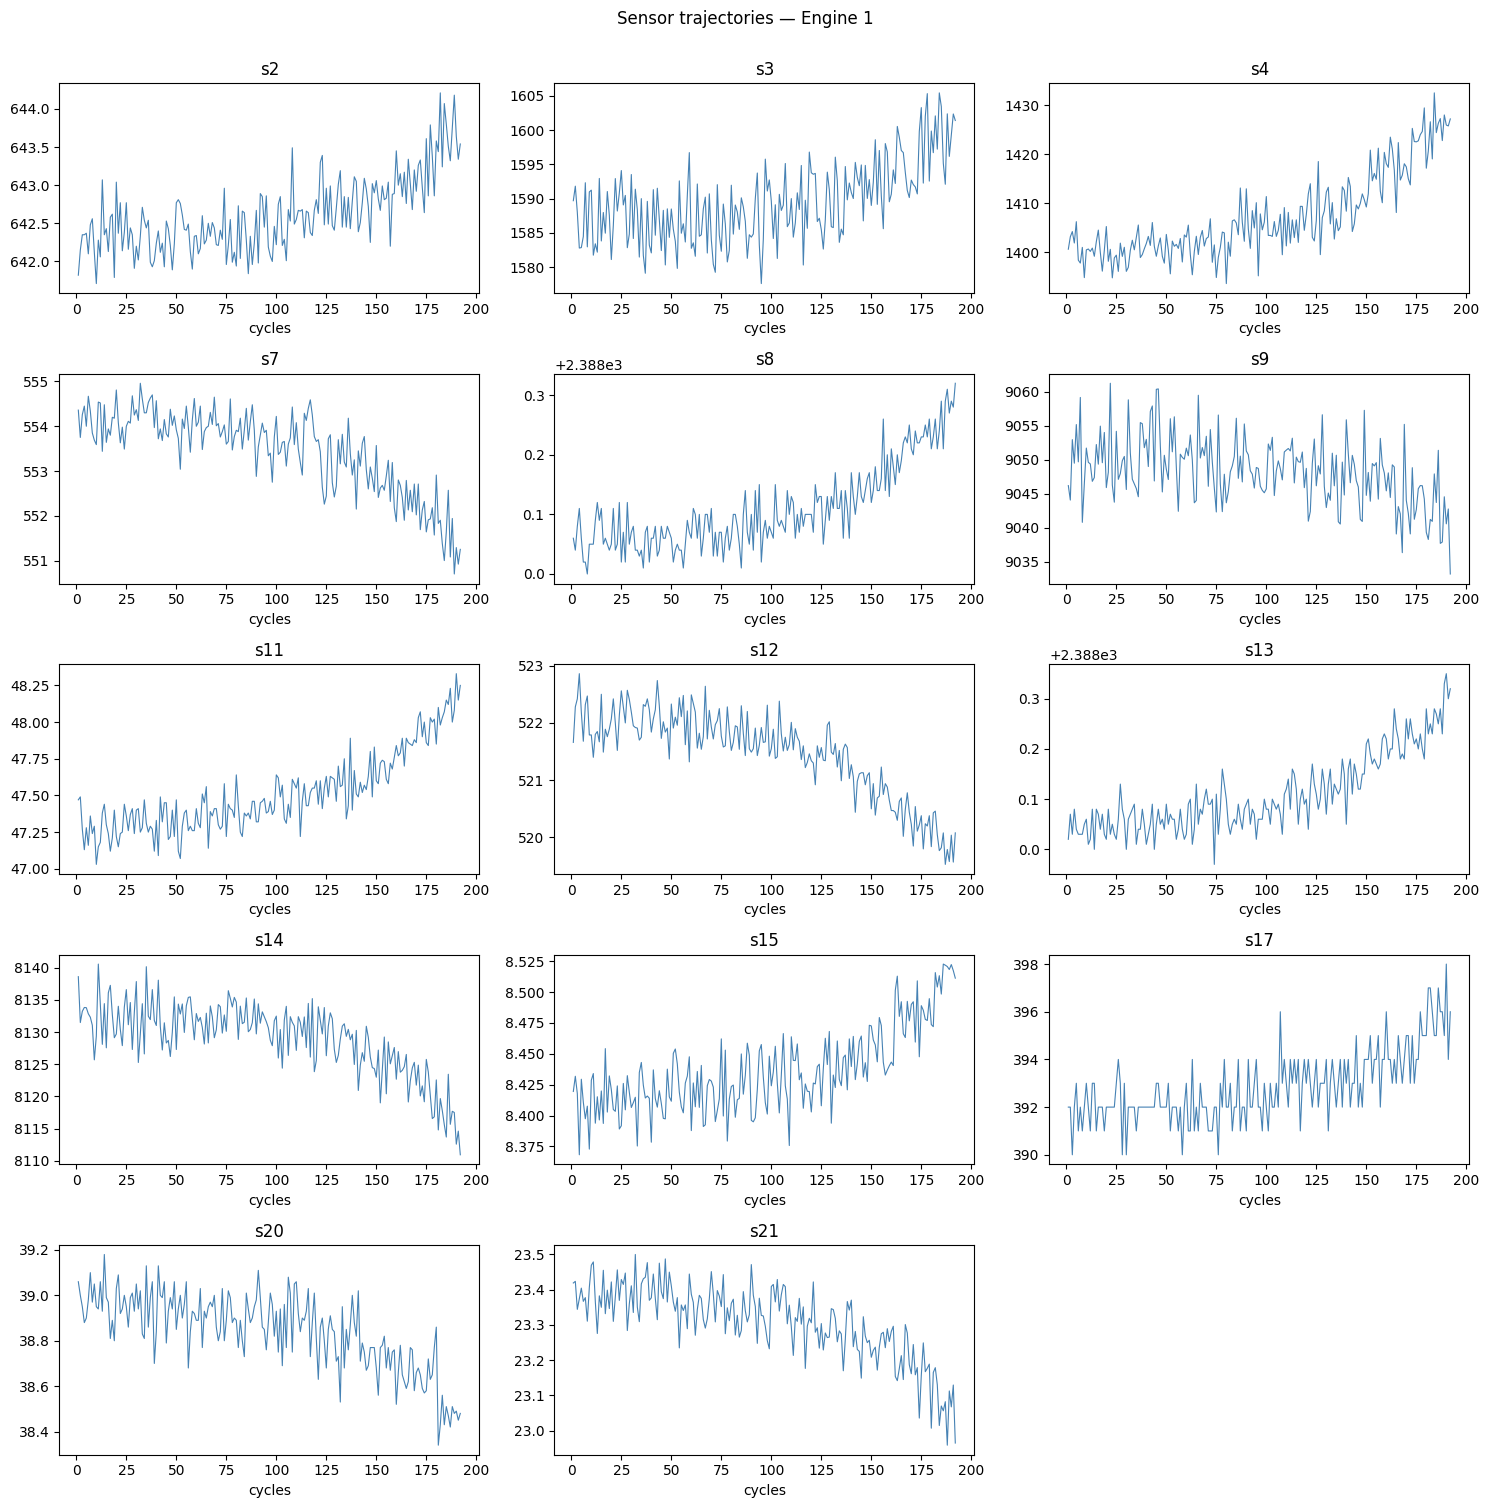

In [8]:
uid = 1   # pick any unit_num
sub = fd1_train[fd1_train["unit_num"] == uid].sort_values("cycles")

n = len(kept_sensor_cols)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = axes.flatten()

for ax, sensor in zip(axes, kept_sensor_cols):
    ax.plot(sub["cycles"], sub[sensor], color="steelblue", linewidth=0.8)
    ax.set_title(sensor)
    ax.set_xlabel("cycles")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f"Sensor trajectories — Engine {uid}", y=1.002)
plt.tight_layout()
plt.show()

fig.savefig(f'../figures/engine_{uid}_sensor_trajectories.png', dpi=150, bbox_inches='tight')

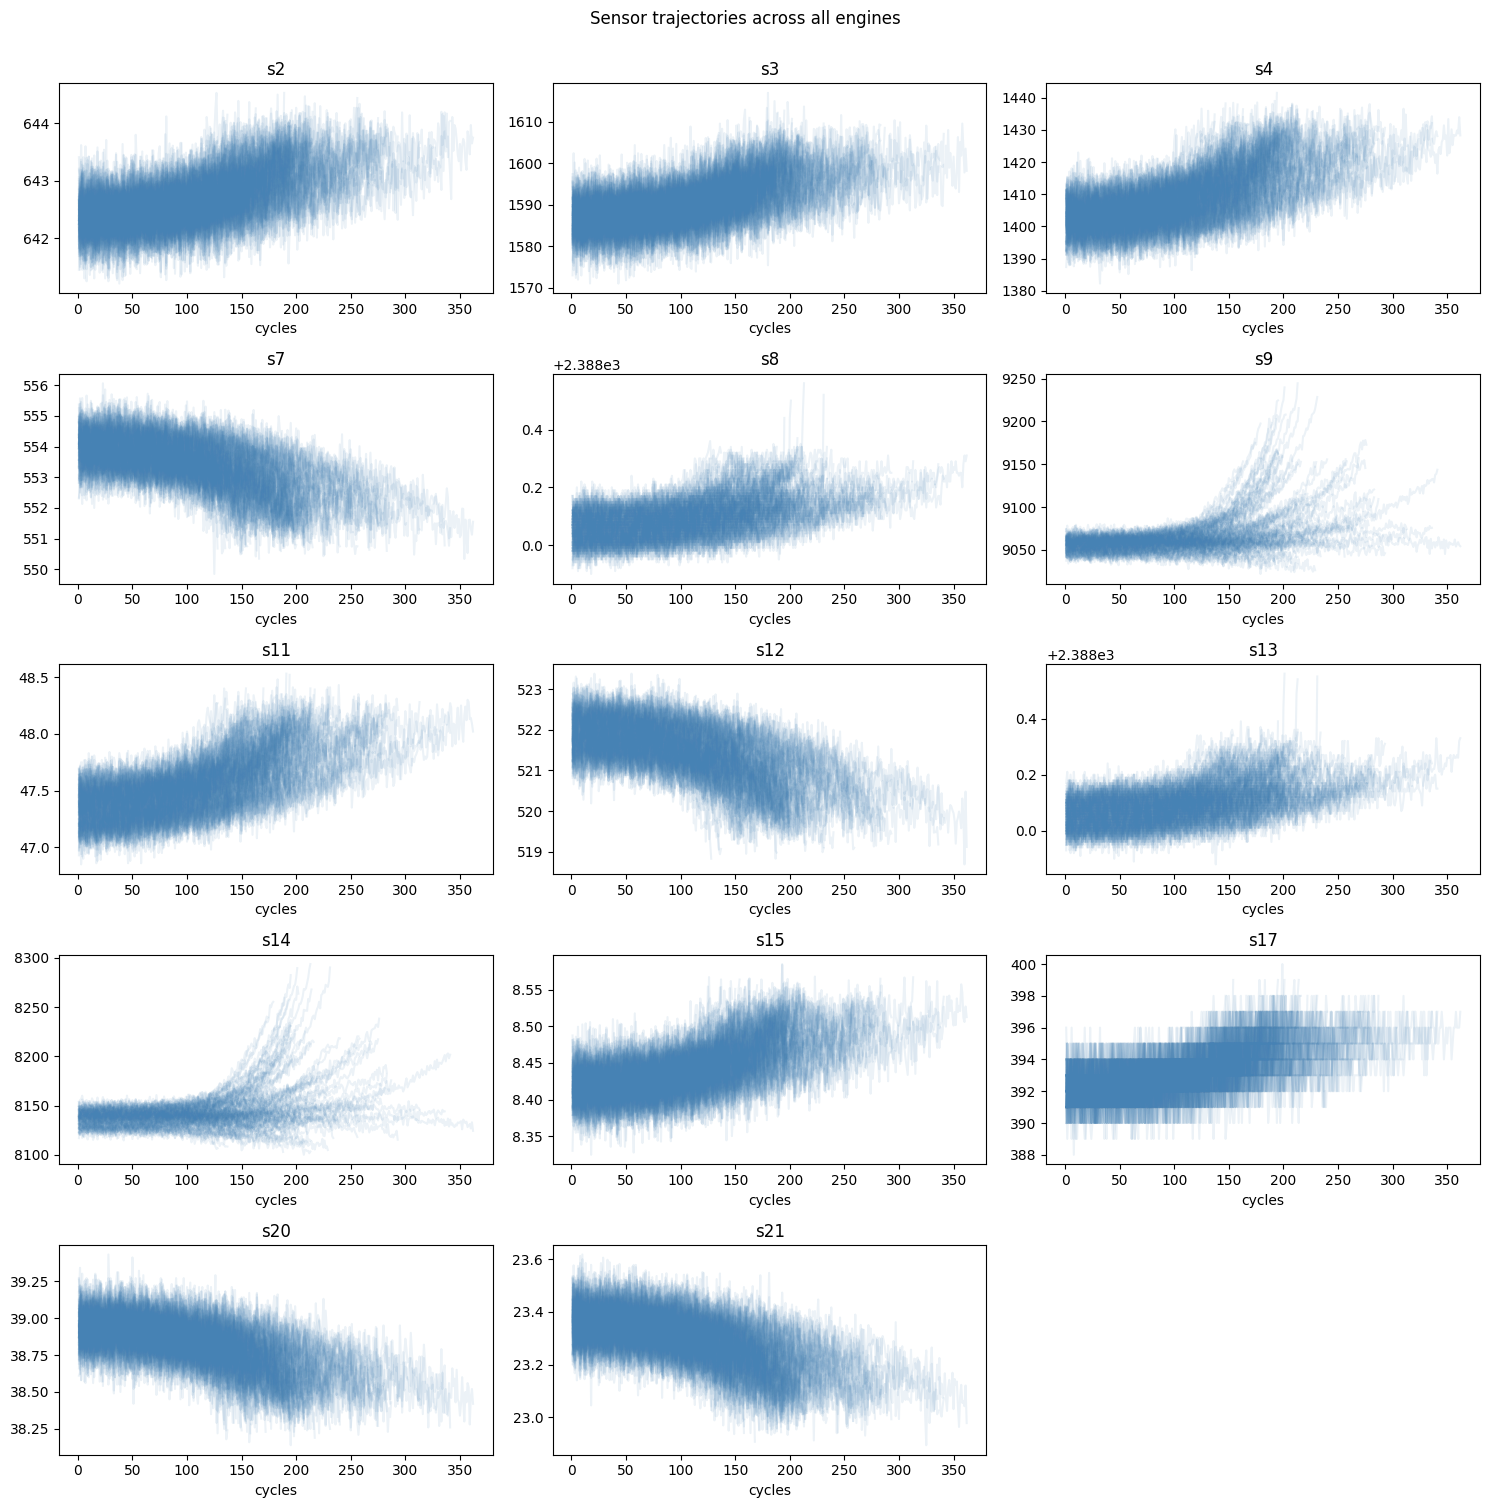

In [9]:
n = len(kept_sensor_cols)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = axes.flatten()

for ax, sensor in zip(axes, kept_sensor_cols):
    for uid in fd1_train["unit_num"].unique():
        sub = fd1_train[fd1_train["unit_num"] == uid]
        ax.plot(sub["cycles"], sub[sensor], alpha=0.1, color="steelblue")
    ax.set_title(sensor)
    ax.set_xlabel("cycles")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Sensor trajectories across all engines", y=1.002)
plt.tight_layout()
plt.show()

fig.savefig('../figures/sensor_trajectories_all_engines.png', dpi=150, bbox_inches='tight')

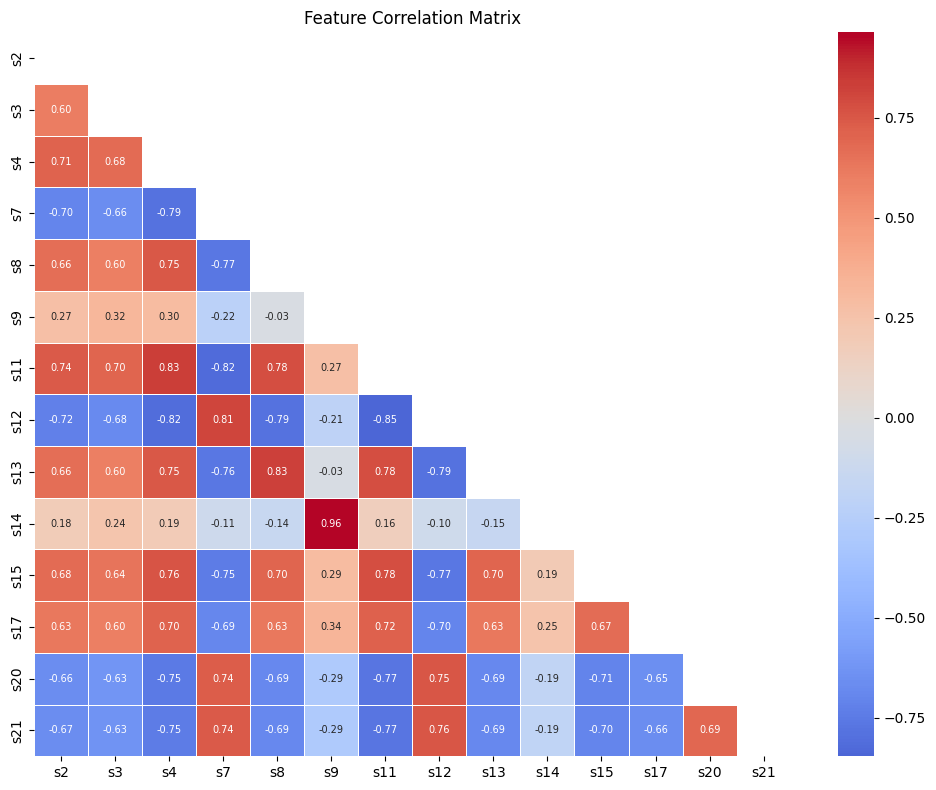

In [10]:
base_cols = [c for c in fd1_train.columns if c not in ("unit_num", "cycles")]
corr = fd1_train[base_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature Correlation Matrix")
fig.tight_layout()
fig.savefig('../figures/feature_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. RUL Label Engineering

RUL is computed as `max_cycle − current_cycle` for each engine. Engines don't degrade meaningfully from the star. Early cycles and mid-life cycles look healthy and indistinguishable from each other. A **piecewise-linear label** (capped at 125) reflects this: above 125 cycles remaining the model simply predicts 125, concentrating learning capacity on the critical degradation window near failure.

In [11]:
max_cycles = fd1_train.groupby("unit_num")["cycles"].transform("max")
fd1_train["RUL"] = (max_cycles - fd1_train["cycles"]).clip(upper=125)
fd1_train[["unit_num", "cycles", "RUL"]].head(10)

,unit_num,cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


## 3. Train / Validation Split

The split is by **engine unit**, not by row, so no engine appears in both sets. A row-level split would leak future cycles of the same engine into training. 80 % of units go to training, 20 % to validation.

In [12]:
feature_cols = [c for c in fd1_train.columns if c not in ["unit_num", "cycles", "RUL"]]

rng = np.random.RandomState(42)

units = fd1_train["unit_num"].unique()
val_units = rng.choice(units, size = int(0.2*len(units)), replace = False)

val_mask = fd1_train["unit_num"].isin(val_units)
train_df = fd1_train[~val_mask]
val_df = fd1_train[val_mask]

X_train, y_train = train_df[feature_cols], train_df["RUL"]
X_val, y_val = val_df[feature_cols], val_df["RUL"]

print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_val.shape:", X_val.shape)
print("y_val.shape:", y_val.shape)

X_train.shape: (16561, 14)
y_train.shape: (16561,)
X_val.shape: (4070, 14)
y_val.shape: (4070,)


## 4. Baseline — Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, pred)) 
print(f"Validation RMSE: {rmse:.2f}")

Validation RMSE: 17.17


In [14]:
near_failure = y_val <= 30
rmse_tail = np.sqrt(mean_squared_error(y_val[near_failure], pred[near_failure]))
print(f"RMSE for RUL <= 30: {rmse_tail:.2f}")

RMSE for RUL <= 30: 9.14


In [15]:
pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

s11    0.565247
s9     0.129203
s4     0.081546
s12    0.035312
s14    0.030032
s7     0.029306
s15    0.024101
s21    0.019300
s3     0.018283
s2     0.018124
s20    0.016137
s13    0.014575
s8     0.012511
s17    0.006324
dtype: float64

## 5. LSTM — Point Estimate

The LSTM receives a **30-cycle rolling window** of scaled sensor readings, capturing temporal degradation patterns a single-snapshot model cannot. Architecture: 1 LSTM layer (64 units) → dense head (32 units, ReLU) → single RUL output. Trained with MSE loss; early stopping on validation RMSE (patience = 7).

In [16]:
from sklearn.preprocessing import MinMaxScaler

train_df = train_df.copy()
val_df = val_df.copy()

# scale the features
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

In [17]:
# create sequences for training and validation
SEQ_LEN = 30

def create_sequences(data, feature_cols, seq_len=SEQ_LEN):
    X, y = [], []
    skipped = []
    for unit, g in data.groupby("unit_num"):
        g = g.sort_values("cycles")
        feats, targets = g[feature_cols].values, g["RUL"].values
        if len(g) < seq_len:
            skipped.append(unit)
            continue
        for i in range(len(g) - seq_len + 1):
            X.append(feats[i:i+seq_len])
            y.append(targets[i+seq_len-1])      # label = RUL at last cycle of window
    if skipped:
        print(f"Warning: {len(skipped)} unit(s) skipped (fewer than {seq_len} cycles): {skipped}")
    return np.array(X), np.array(y)

X_tr, y_tr = create_sequences(train_df, feature_cols)
X_vl, y_vl = create_sequences(val_df, feature_cols)
print(X_tr.shape, X_vl.shape)


(14241, 30, 14) (3490, 30, 14)


In [18]:
RUL_CAP = 125.0   # piecewise-linear RUL cap

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y / RUL_CAP, dtype=torch.float32).unsqueeze(1)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_vl, y_vl), batch_size=256, shuffle=False)

In [19]:
# Define LSTM for Regression

class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # last timestep only

device = "cuda" if torch.cuda.is_available() else "cpu"
model_reg = LSTMRegressor(len(feature_cols), num_layers=1, dropout=0.0).to(device)
opt = torch.optim.Adam(model_reg.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
loss_fn = nn.MSELoss()

best_val_rmse = float("inf")
patience_reg, bad_epochs_reg = 7, 0
best_reg_state = None

for epoch in range(1, 51):
    model_reg.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss_fn(model_reg(xb), yb).backward()
        nn.utils.clip_grad_norm_(model_reg.parameters(), max_norm=1.0)
        opt.step()

    model_reg.eval()
    with torch.no_grad():
        preds = torch.cat([model_reg(xb.to(device)).cpu() for xb, _ in val_loader]) * RUL_CAP
        trues = torch.cat([yb for _, yb in val_loader]) * RUL_CAP
        val_rmse = torch.sqrt(loss_fn(preds, trues)).item()
        scheduler.step(val_rmse)

    if val_rmse < best_val_rmse - 1e-3:
        best_val_rmse, bad_epochs_reg = val_rmse, 0
        best_reg_state = {k: v.cpu().clone() for k, v in model_reg.state_dict().items()}
    else:
        bad_epochs_reg += 1

    print(f"epoch {epoch:2d}   val RMSE {val_rmse:.2f}" + ("   *" if bad_epochs_reg == 0 else ""))

    if bad_epochs_reg >= patience_reg:
        print(f"early stop at epoch {epoch} (best val RMSE {best_val_rmse:.2f})")
        break

model_reg.load_state_dict(best_reg_state)

epoch  1   val RMSE 39.33   *
epoch  2   val RMSE 20.56   *
epoch  3   val RMSE 19.01   *
epoch  4   val RMSE 16.44   *
epoch  5   val RMSE 14.72   *
epoch  6   val RMSE 14.45   *
epoch  7   val RMSE 13.72   *
epoch  8   val RMSE 13.07   *
epoch  9   val RMSE 13.72
epoch 10   val RMSE 12.52   *
epoch 11   val RMSE 13.14
epoch 12   val RMSE 13.06
epoch 13   val RMSE 12.79
epoch 14   val RMSE 12.78
epoch 15   val RMSE 12.03   *
epoch 16   val RMSE 12.04
epoch 17   val RMSE 12.72
epoch 18   val RMSE 12.82
epoch 19   val RMSE 12.42
epoch 20   val RMSE 12.13
epoch 21   val RMSE 12.17
epoch 22   val RMSE 12.13
early stop at epoch 22 (best val RMSE 12.03)


<All keys matched successfully>

## 6. Test Set Evaluation

In [20]:
assert 'drop_cols' in globals(), "Run the feature selection cell first (drop_cols undefined)"
assert 'feature_cols' in globals(), "Run the train/val split cell first (feature_cols undefined)"
assert 'scaler' in globals(), "Run the LSTM preprocessing cell first (scaler undefined)"
assert 'rf' in globals(), "Run the Random Forest cell first (rf undefined)"
assert 'model_reg' in globals(), "Run the LSTM training cell first (model_reg undefined)"

# Load test data and drop the same columns as in training
fd1_test = fd1_test.drop(columns=drop_cols)

# cap test RUL at 125 cycles
rul_test["RUL"] = rul_test["RUL"].clip(upper=125)

# RF evaluate on test set 
last_raw = (fd1_test.sort_values(["unit_num", "cycles"]).groupby("unit_num").tail(1).sort_values("unit_num").reset_index(drop=True))
pred_rf = rf.predict(last_raw[feature_cols])

# NASA asymmetric score — penalises late predictions 
def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)))

print(f"Test RMSE  (RF):   {round(np.sqrt(mean_squared_error(rul_test['RUL'], pred_rf)), 2)}")
print(f"NASA score (RF):   {nasa_score(rul_test['RUL'], pred_rf):.0f}")

# Scale test set for LSTM evaluation
fd1_test_scaled = fd1_test.copy()
fd1_test_scaled[feature_cols] = scaler.transform(fd1_test_scaled[feature_cols])

def get_last_sequence(data, feature_cols, seq_len=30):
    X = []
    for _, g in data.groupby("unit_num"):
        g = g.sort_values("cycles")
        feats = g[feature_cols].values
        if len(feats) < seq_len:
            # front-pad by repeating the earliest real cycle (NOT scaled zeros)
            pad = np.repeat(feats[:1], seq_len - len(feats), axis=0)
            feats = np.vstack([pad, feats])
        X.append(feats[-seq_len:])
    return np.array(X)

X_test_lstm = get_last_sequence(fd1_test_scaled, feature_cols)
X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32).to(device)

model_reg.eval()
with torch.no_grad():
    pred_lstm = model_reg(X_test_tensor).cpu().numpy().flatten() * RUL_CAP

rmse_lstm = np.sqrt(mean_squared_error(rul_test["RUL"], pred_lstm))
print(f"Test RMSE  (LSTM): {rmse_lstm:.2f}")
print(f"NASA score (LSTM): {nasa_score(rul_test['RUL'], pred_lstm):.0f}")

Test RMSE  (RF):   16.57
NASA score (RF):   811
Test RMSE  (LSTM): 13.80
NASA score (LSTM): 352


## 7. Uncertainty-Aware Prediction (Quantile LSTM)

Point estimate with prediction intervals provides engineers more actionable information in maintenence decision. Therefore, we'll extend the LSTM with quantile regression to produce 3 quantiles at 5%, 50% and 95%. Training uses quantile less to penalize overconfidence. 

In [21]:
# Define LSTM for quantile regression

QUANTILES = [0.05, 0.5, 0.95]   

class LSTMQuantile(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(),
                                  nn.Linear(32, len(QUANTILES)))  # 3 outputs
    def forward(self, x):
        out, _ = self.lstm(x)
        raw = self.head(out[:, -1, :])
        return raw.sort(dim=1).values   # enforce p5 <= p50 <= p95 during training too

def quantile_loss(preds, target, quantiles=QUANTILES):
    losses = []
    for i, q in enumerate(quantiles):
        err = target - preds[:, i:i+1]
        losses.append(torch.max(q * err, (q - 1) * err))
    return torch.mean(torch.sum(torch.cat(losses, dim=1), dim=1))


def combined_loss(preds, target, alpha=0.3):
    """Pinball + MSE anchor on p50 — prevents mean collapse."""
    return quantile_loss(preds, target) + alpha * nn.MSELoss()(preds[:, 1:2], target)


In [22]:
# Train quantile model 

train_loader_q = DataLoader(SeqDataset(X_tr, y_tr), batch_size=512, shuffle=True)
val_loader_q   = DataLoader(SeqDataset(X_vl, y_vl), batch_size=512, shuffle=False)

model_q = LSTMQuantile(len(feature_cols)).to(device)
opt = torch.optim.Adam(model_q.parameters(), lr=3e-3)
scheduler_q = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

best_val = float("inf")
patience, bad_epochs = 6, 0
best_state = None

for epoch in range(1, 61):          # cap high; early stopping decides the real number
    model_q.train()
    for xb, yb in train_loader_q:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        combined_loss(model_q(xb), yb).backward()
        nn.utils.clip_grad_norm_(model_q.parameters(), max_norm=1.0)
        opt.step()

    model_q.eval()
    with torch.no_grad():
        preds = torch.cat([model_q(xb.to(device)).cpu() for xb, _ in val_loader_q])
        trues = torch.cat([yb for _, yb in val_loader_q])
        val_loss = combined_loss(preds, trues).item()
    scheduler_q.step(val_loss)

    if val_loss < best_val - 1e-4:          # improved
        best_val, bad_epochs = val_loss, 0
        best_state = {k: v.cpu().clone() for k, v in model_q.state_dict().items()}
    else:
        bad_epochs += 1

    print(f"epoch {epoch:2d}   val loss {val_loss:.3f}   lr {opt.param_groups[0]['lr']:.1e}"
          + ("   *" if bad_epochs == 0 else ""))

    if bad_epochs >= patience:
        print(f"early stop at epoch {epoch} (best val {best_val:.3f})")
        break

model_q.load_state_dict(best_state)

epoch  1   val loss 0.234   lr 3.0e-03   *
epoch  2   val loss 0.124   lr 3.0e-03   *
epoch  3   val loss 0.090   lr 3.0e-03   *
epoch  4   val loss 0.071   lr 3.0e-03   *
epoch  5   val loss 0.066   lr 3.0e-03   *
epoch  6   val loss 0.063   lr 3.0e-03   *
epoch  7   val loss 0.058   lr 3.0e-03   *
epoch  8   val loss 0.058   lr 3.0e-03
epoch  9   val loss 0.059   lr 3.0e-03
epoch 10   val loss 0.057   lr 3.0e-03   *
epoch 11   val loss 0.055   lr 3.0e-03   *
epoch 12   val loss 0.057   lr 3.0e-03
epoch 13   val loss 0.056   lr 3.0e-03
epoch 14   val loss 0.060   lr 3.0e-03
epoch 15   val loss 0.055   lr 3.0e-03   *
epoch 16   val loss 0.053   lr 3.0e-03   *
epoch 17   val loss 0.054   lr 3.0e-03
epoch 18   val loss 0.053   lr 3.0e-03
epoch 19   val loss 0.057   lr 3.0e-03
epoch 20   val loss 0.054   lr 1.5e-03
epoch 21   val loss 0.055   lr 1.5e-03
epoch 22   val loss 0.052   lr 1.5e-03   *
epoch 23   val loss 0.056   lr 1.5e-03
epoch 24   val loss 0.053   lr 1.5e-03
epoch 25   val l

<All keys matched successfully>

In [23]:
model_q.eval()
with torch.no_grad():
    preds_val = torch.cat([model_q(xb.to(device)).cpu() for xb, _ in val_loader_q]).numpy() * RUL_CAP
    trues_val = torch.cat([yb for _, yb in val_loader_q]).numpy().flatten() * RUL_CAP

lo, mid, hi = preds_val[:, 0], preds_val[:, 1], preds_val[:, 2]
coverage = ((trues_val >= lo) & (trues_val <= hi)).mean()
p50_rmse = np.sqrt(mean_squared_error(trues_val, mid))

print(f"Val p50 RMSE:        {p50_rmse:.2f}")
print(f"Val 90% coverage:    {coverage:.3f}   (target 0.90)")
print(f"Mean interval width: {(hi - lo).mean():.1f} cycles")

print(f"Val RUL  — mean: {trues_val.mean():.1f}  median: {np.median(trues_val):.1f}  max: {trues_val.max():.0f}")
print(f"Test RUL — mean: {rul_test['RUL'].mean():.1f}  median: {rul_test['RUL'].median():.1f}  max: {rul_test['RUL'].max():.0f}")


Val p50 RMSE:        12.13
Val 90% coverage:    0.936   (target 0.90)
Mean interval width: 35.5 cycles
Val RUL  — mean: 79.9  median: 87.0  max: 125
Test RUL — mean: 74.5  median: 86.0  max: 125


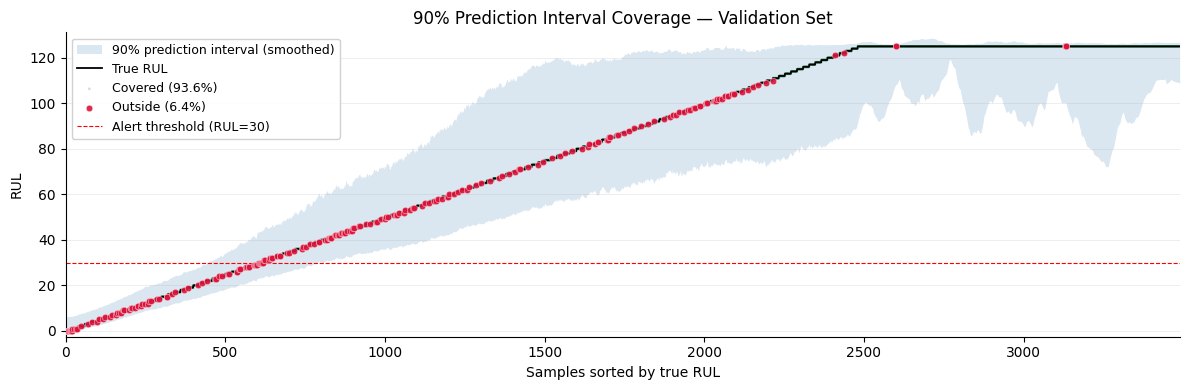

In [24]:
# Coverage plot 
sorted_idx = np.argsort(trues_val.flatten())
strue = trues_val.flatten()[sorted_idx]
slo   = preds_val[:, 0][sorted_idx]
shi   = preds_val[:, 2][sorted_idx]
cov   = (strue >= slo) & (strue <= shi)
x     = np.arange(len(strue))

# Rolling-smoothed interval bound
w = max(25, len(strue) // 70)
roll = lambda a: pd.Series(a).rolling(w, center=True, min_periods=1).mean().values
slo_s, shi_s = roll(slo), roll(shi)

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(x, slo_s, shi_s, alpha=0.20, color='steelblue',
                linewidth=0, label='90% prediction interval (smoothed)')
ax.plot(x, strue, color='black', linewidth=1.3, label='True RUL', zorder=3)

ax.scatter(x[cov],  strue[cov],  s=4,  color='seagreen', alpha=0.25,
           edgecolors='none', label=f'Covered ({cov.mean():.1%})', zorder=2)
ax.scatter(x[~cov], strue[~cov], s=22, color='crimson', alpha=0.9,
           edgecolors='white', linewidths=0.3,
           label=f'Outside ({(~cov).mean():.1%})', zorder=4)

ax.axhline(30, color='red', linestyle='--', linewidth=0.8, label='Alert threshold (RUL=30)')

ax.set_xlabel('Samples sorted by true RUL')
ax.set_ylabel('RUL')
ax.set_title('90% Prediction Interval Coverage — Validation Set')
ax.set_xlim(0, len(strue))
ax.margins(y=0.02)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

fig.savefig('../figures/coverage_plot.png', dpi=150, bbox_inches='tight')

In [25]:
X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32).to(device)

model_q.eval()
with torch.no_grad():
    preds_test = model_q(X_test_tensor).cpu().numpy() * RUL_CAP

y_true = rul_test["RUL"].values
lo, mid, hi = preds_test[:, 0], preds_test[:, 1], preds_test[:, 2]

def pinball_np(y, q_preds, quantiles=QUANTILES):
    return sum(np.mean(np.maximum(q * (y - q_preds[:, i]), (q - 1) * (y - q_preds[:, i])))
               for i, q in enumerate(quantiles))

print(f"Test p50 RMSE (LSTM-Q): {np.sqrt(mean_squared_error(y_true, mid)):.2f}")
print(f"Test 90% coverage:      {((y_true >= lo) & (y_true <= hi)).mean():.3f}")
print(f"Test pinball loss:      {pinball_np(y_true, preds_test):.3f}")
print(f"Test NASA score (LSTM-Q): {nasa_score(y_true, mid):.0f}")


Test p50 RMSE (LSTM-Q): 14.48
Test 90% coverage:      0.880
Test pinball loss:      7.739
Test NASA score (LSTM-Q): 460


## 8. Model Comparison

In [26]:
model_reg.eval()
with torch.no_grad():
    _p = torch.cat([model_reg(xb.to(device)).cpu() for xb, _ in val_loader]).numpy().flatten() * RUL_CAP
    _t = torch.cat([yb for _, yb in val_loader]).numpy().flatten() * RUL_CAP
rmse_lstm_val = float(np.sqrt(mean_squared_error(_t, _p)))

nasa_rf   = nasa_score(y_true, pred_rf)
nasa_lstm = nasa_score(y_true, pred_lstm)
nasa_q    = nasa_score(y_true, mid)

summary = pd.DataFrame({
    'Model':             ['Random Forest', 'LSTM (point)', 'LSTM-Quantile (p50)'],
    'Input context':     ['1 cycle snapshot', '30-cycle window', '30-cycle window'],
    'Val RMSE':          [round(float(np.sqrt(mean_squared_error(y_val, rf.predict(X_val)))), 2), round(rmse_lstm_val, 2), round(p50_rmse, 2)],
    'Test RMSE':         [
        round(float(np.sqrt(mean_squared_error(y_true, pred_rf))), 2),
        round(float(rmse_lstm), 2),
        round(float(np.sqrt(mean_squared_error(y_true, mid))), 2),
    ],
    '90% CI Coverage':   ['—', '—', f'{coverage:.1%}'],
    'NASA Score':        [f'{nasa_rf:.0f}', f'{nasa_lstm:.0f}', f'{nasa_q:.0f}'],
})
summary

,Model,Input context,Val RMSE,Test RMSE,90% CI Coverage,NASA Score
0,Random Forest,1 cycle snapshot,17.17,16.57,—,811
1,LSTM (point),30-cycle window,12.03,13.80,—,352
2,LSTM-Quantile (p50),30-cycle window,12.13,14.48,93.6%,460


### Predicted vs True RUL — Test Set

Points on the diagonal represent perfect predictions. The RF over-predicts at low RUL (engines near failure appear healthier than they are). The LSTM-Quantile tracks the full range more evenly.

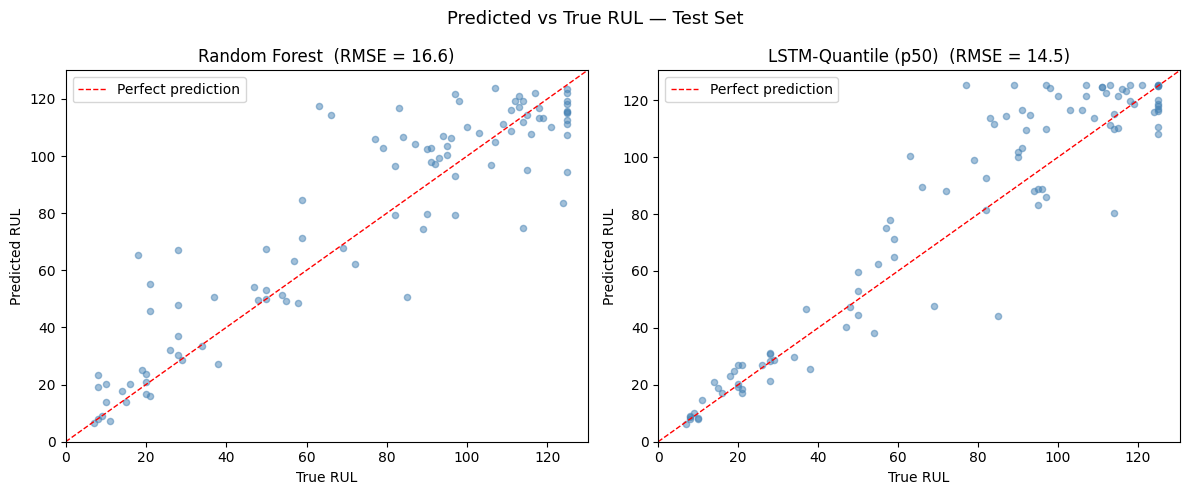

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, preds) in zip(axes, [
        ('Random Forest', pred_rf),
        ('LSTM-Quantile (p50)', mid)]):
    ax.scatter(y_true, preds, alpha=0.5, s=20, color='steelblue')
    lim = [0, max(float(y_true.max()), float(preds.max())) + 5]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
    _rmse = float(np.sqrt(mean_squared_error(y_true, preds)))
    ax.set_xlabel('True RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(f'{label}  (RMSE = {_rmse:.1f})')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend()

plt.suptitle('Predicted vs True RUL — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

fig.savefig('../figures/predicted_vs_true_rul.png', dpi=150, bbox_inches='tight')

## 9. Per-Unit RUL Trajectory

Plotting the full degradation trajectory for a given validation unit 

In [28]:
def sequences_for_unit(data, feature_cols, seq_len=SEQ_LEN):
    """One padded sequence per cycle so we can plot RUL trajectory."""
    data = data.sort_values("cycles")
    feats = data[feature_cols].values
    X = []
    for i in range(len(feats)):
        end = i + 1
        start = end - seq_len
        if start < 0:
            pad = np.repeat(feats[:1], -start, axis=0)
            seq = np.vstack([pad, feats[:end]])
        else:
            seq = feats[start:end]
        X.append(seq)
    return np.array(X)


Selected unit 71  (MAE = 7.2,  val-median MAE = 7.1)


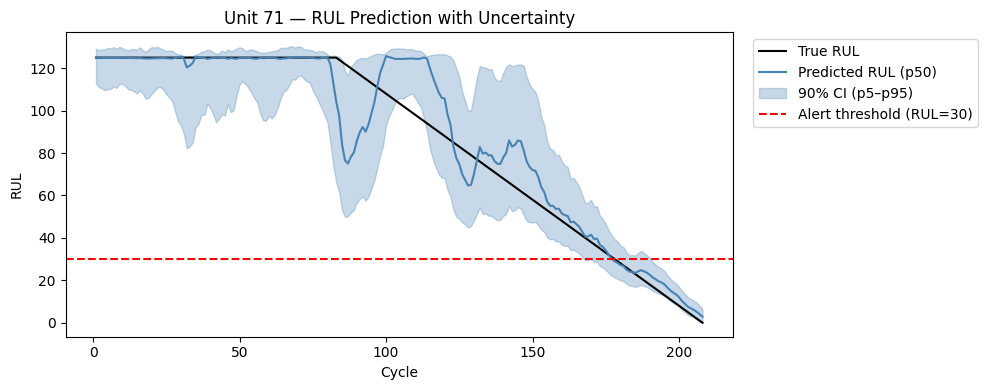

In [29]:
# Select the unit closest to median MAE across all validation units
model_q.eval()
unit_maes = {}
for uid in val_units:
    udata = val_df[val_df.unit_num == uid].sort_values('cycles')
    if len(udata) == 0:
        continue
    X_u = sequences_for_unit(udata, feature_cols)
    with torch.no_grad():
        p = model_q(torch.tensor(X_u, dtype=torch.float32).to(device)).cpu().numpy() * RUL_CAP
    unit_maes[uid] = float(np.mean(np.abs(udata['RUL'].values - p[:, 1])))

median_mae = float(np.median(list(unit_maes.values())))
unit_id = min(unit_maes, key=lambda u: abs(unit_maes[u] - median_mae))
print(f'Selected unit {unit_id}  '
      f'(MAE = {unit_maes[unit_id]:.1f},  val-median MAE = {median_mae:.1f})')

unit_data = val_df[val_df.unit_num == unit_id].sort_values('cycles')
X_unit = sequences_for_unit(unit_data, feature_cols)
X_tensor = torch.tensor(X_unit, dtype=torch.float32).to(device)

with torch.no_grad():
    preds_unit = model_q(X_tensor).cpu().numpy() * RUL_CAP

cycles, true_rul = unit_data['cycles'].values, unit_data['RUL'].values

plt.figure(figsize=(10, 4))
plt.plot(cycles, true_rul, color='black', label='True RUL')
plt.plot(cycles, preds_unit[:, 1], color='steelblue', label='Predicted RUL (p50)')
plt.fill_between(cycles, preds_unit[:, 0], preds_unit[:, 2],
                 alpha=0.3, color='steelblue', label='90% CI (p5–p95)')
plt.axhline(30, color='red', linestyle='--', label='Alert threshold (RUL=30)')
plt.xlabel('Cycle'); plt.ylabel('RUL')
plt.title(f'Unit {unit_id} — RUL Prediction with Uncertainty')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig.savefig(f'../figures/unit_{unit_id}_rul_prediction.png', dpi=150, bbox_inches='tight')

## 10. Conclusions

The LSTM-Quantile achieves a test RMSE of 14.48 cycles and 90% CI coverage of 93.6% , versus an Random Forest baseline RMSE of 16.57 The NASA score was also reported alongside the LSTM-Quantile showing that the LSTM-Quantile improved the accuracy of the engine RUL scoring 460 versus the Random Forest NASA score of 811. The LSTM regressor had the best NASA score of 352.

**Takeaways**

- LSTM reduced test RMSE compared to Random Forest by accounting for 30 cycle window history and NASA score improved tremendously 
- Quanitle regression offers actionable insight for maintenance team as the 90% CI bound hits close to target. The model is well-calibrated
- Sensor channel pruning helped, we dropped many sensors to reduce noise while maximizing information
- MSE anchored on p50 stops quantile regression from collapsing the the dataset mean
- Single cycle snapshots can't distinguish early-life and mid-life cycles.

**Limitations & next steps:**
- FD001 covers a single operating condition and fault mode
- Prediction intervals are wide for long-life engines; conformal prediction could tighten them with coverage guarantees